# Módulo III: Big Data y la Analítica de Datos para la Toma de Decisiones
## Unidad II: Machine Learning: Modelos Supervisados y No Supervisados
### **Notebook Formativo 5: Aprendizaje Supervisado y Regresión**

**Modelado de una variable continua de planta con Scikit-Learn**  
**Diplomado:** Gestión Industrial y Analítica de Datos — FCyT UMSS

---

## Propósito de la sesión

Este cuaderno desarrolla un primer experimento supervisado completo: formular una pregunta predictiva, separar los datos, establecer una referencia, entrenar regresores y evaluar su desempeño sobre observaciones no utilizadas durante el ajuste.

Al finalizar, usted podrá:

1. Formular un **contrato predictivo** con decisión, unidad de observación, horizonte, objetivo $y$ y predictores $X$.
2. Seleccionar una estrategia de partición coherente con el uso previsto del modelo.
3. Evitar fugas de información mediante un `Pipeline` de Scikit-Learn.
4. Comparar `DummyRegressor`, Regresión Lineal y Random Forest con las mismas observaciones de prueba.
5. Interpretar MAE, MSE, RMSE y $R^2$ sin confundir una métrica con impacto operativo.
6. Examinar residuos y documentar limitaciones antes de recomendar una decisión.

> **Evidencia formativa:** notebook ejecutable, tabla comparativa en TEST y una interpretación técnica breve.


## 0. Preparación del entorno

La semilla permite repetir la simulación y comparar resultados durante el taller; **no garantiza** que la partición sea representativa ni que el modelo sea válido para producción.

Usaremos objetos `Pipeline` para asegurar que cualquier transformación aprendida se ajuste exclusivamente con el conjunto de entrenamiento.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

SEMILLA = 42
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print(f"Semilla didáctica: {SEMILLA}")
print(sklearn.__version__)


Python 3.13.15 | pandas 2.2.3 | scikit-learn 1.6.1
Semilla didáctica: 42
1.6.1


## 1. Capa Silver didáctica: ventanas operativas de 30 minutos

Para que el notebook sea autocontenido, simularemos una tabla Silver de un turbocompresor. Cada fila representa una **ventana futura inmediata de 30 minutos**:

- `timestamp_inicio`: instante en que se genera la predicción.
- `temperatura_c`: temperatura disponible al inicio de la ventana.
- `vibracion_mm_s`: vibración disponible al inicio.
- `horas_desde_mantenimiento`: horas acumuladas desde el último mantenimiento.
- `produccion_plan_t_h`: consigna de producción disponible al inicio.
- `energia_kwh_30m`: energía observada al finalizar la ventana; será el objetivo continuo.

> Los datos son sintéticos y sirven para aprender el flujo. Las métricas obtenidas **no constituyen evidencia de desempeño en una planta real**.


In [ ]:
rng = np.random.default_rng(SEMILLA)
n_muestras = 600
paso = np.arange(n_muestras)

timestamp_inicio = pd.date_range(
    start="2026-01-01 00:00:00",
    periods=n_muestras,
    freq="30min",
    tz="UTC",
)

# Señales disponibles al inicio de cada ventana
temperatura = 70 + 4.5 * np.sin(2 * np.pi * paso / 48) + rng.normal(0, 2.8, n_muestras)
horas_desde_mantenimiento = (paso * 0.5) % 240
vibracion = np.clip(
    2.4 + 0.004 * horas_desde_mantenimiento + rng.normal(0, 0.35, n_muestras),
    0.4,
    None,
)
produccion_plan = 23 + 2.2 * np.sin(2 * np.pi * paso / 16) + rng.normal(0, 0.9, n_muestras)

# Energía acumulada durante los 30 minutos posteriores al timestamp_inicio
energia = (
    82.0
    + 5.6 * produccion_plan
    + 0.75 * temperatura
    + 9.0 * np.log1p(vibracion)
    + 0.035 * horas_desde_mantenimiento
    + 0.06 * temperatura * vibracion
    + rng.normal(0, 6.0, n_muestras)
)

df_silver = pd.DataFrame({
    "id_registro": [f"REG-{i:04d}" for i in range(1, n_muestras + 1)],
    "timestamp_inicio": timestamp_inicio,
    "temperatura_c": temperatura,
    "vibracion_mm_s": vibracion,
    "horas_desde_mantenimiento": horas_desde_mantenimiento,
    "produccion_plan_t_h": produccion_plan,
    "energia_kwh_30m": energia,
})

print(f"Capa Silver simulada: {df_silver.shape[0]} filas × {df_silver.shape[1]} columnas")
display(df_silver.head())


Capa Silver simulada: 600 filas × 7 columnas


,id_registro,timestamp_inicio,temperatura_c,vibracion_mm_s,horas_desde_mantenimiento,produccion_plan_t_h,energia_kwh_30m
0,REG-0001,2026-01-01 00:00:00+00:00,70.853,2.580,0.000,21.810,279.485
1,REG-0002,2026-01-01 00:30:00+00:00,67.675,2.200,0.500,23.404,285.894
2,REG-0003,2026-01-01 01:00:00+00:00,73.266,2.850,1.000,24.934,299.449
3,REG-0004,2026-01-01 01:30:00+00:00,74.356,2.186,1.500,24.940,295.211
4,REG-0005,2026-01-01 02:00:00+00:00,66.787,2.185,2.000,24.614,289.739


### Control mínimo antes de modelar

Aunque la tabla se denomine Silver, el analista debe comprobar su estructura. Las aserciones siguientes funcionan como un contrato mínimo: identificadores únicos, orden temporal, ausencia de nulos y valores físicamente válidos para este ejercicio.


In [ ]:
columnas_numericas = [
    "temperatura_c",
    "vibracion_mm_s",
    "horas_desde_mantenimiento",
    "produccion_plan_t_h",
    "energia_kwh_30m",
]

assert df_silver["id_registro"].is_unique, "Hay identificadores duplicados."
assert df_silver["timestamp_inicio"].is_monotonic_increasing, "La secuencia temporal no está ordenada."
assert df_silver[columnas_numericas].notna().all().all(), "Hay nulos en variables críticas."
assert np.isfinite(df_silver[columnas_numericas].to_numpy()).all(), "Hay valores no finitos."
assert df_silver["energia_kwh_30m"].gt(0).all(), "La energía debe ser positiva."
assert df_silver["produccion_plan_t_h"].gt(0).all(), "La consigna de producción debe ser positiva."

print("Controles de integridad superados.")
display(df_silver[columnas_numericas].describe().T)


Controles de integridad superados.


,count,mean,std,min,25%,50%,75%,max
temperatura_c,600.000,70.041,4.071,60.626,67.030,70.033,73.113,82.031
vibracion_mm_s,600.000,2.801,0.460,1.614,2.473,2.803,3.137,4.337
horas_desde_mantenimiento,600.000,101.750,72.143,0.000,37.375,89.750,164.625,239.500
produccion_plan_t_h,600.000,22.947,1.824,18.300,21.505,22.919,24.409,27.086
energia_kwh_30m,600.000,290.031,13.106,245.020,280.487,290.173,298.881,326.573


## 2. Contrato predictivo

- **Decisión:** priorizar una revisión energética o ajustar la planificación de la siguiente ventana; el modelo no actúa sobre el control de planta de forma autónoma.
- **Unidad de observación:** una ventana de operación de 30 minutos.
- **Instante de predicción:** inicio de la ventana.
- **Horizonte:** energía acumulada durante los siguientes 30 minutos.
- **Objetivo $y$:** `energia_kwh_30m` en kWh.
- **Predictores $X$:** únicamente señales y consignas disponibles al inicio.

Esta definición evita utilizar información generada después de la predicción y permite interpretar el error en una unidad física.


In [ ]:
predictores = [
    "temperatura_c",
    "vibracion_mm_s",
    "horas_desde_mantenimiento",
    "produccion_plan_t_h",
]
objetivo = "energia_kwh_30m"

X = df_silver[predictores].copy()
y = df_silver[objetivo].copy()

print("X:", predictores)
print(f"y: {objetivo} | unidad: kWh por ventana de 30 minutos")
print(f"Unidad de observación: {len(X)} ventanas")


X: ['temperatura_c', 'vibracion_mm_s', 'horas_desde_mantenimiento', 'produccion_plan_t_h']
y: energia_kwh_30m | unidad: kWh por ventana de 30 minutos
Unidad de observación: 600 ventanas


## 3. Partición temporal: entrenamiento y prueba

Como las observaciones tienen un orden temporal, utilizaremos las primeras 80% para entrenamiento y las últimas 20% como prueba. Esto imita mejor la pregunta: **¿cómo se comportará el modelo en ventanas posteriores?**

El 80/20 es una decisión didáctica, no una ley universal. En el Proyecto Integrador, la partición debe responder al escenario real:

- **Temporal:** si se predecirá el futuro.
- **Por activo, lote o planta:** si se evaluará generalización a entidades nuevas.
- **Aleatoria:** solo cuando las filas sean aproximadamente independientes y representen la misma población.

> TEST es una aproximación fuera de muestra; no equivale a una validación de campo ni garantiza desempeño futuro.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False,
)

assert set(X_train.index).isdisjoint(X_test.index)
assert X_train.index.max() < X_test.index.min()

fecha_train_inicio = df_silver.loc[X_train.index.min(), "timestamp_inicio"]
fecha_train_fin = df_silver.loc[X_train.index.max(), "timestamp_inicio"]
fecha_test_inicio = df_silver.loc[X_test.index.min(), "timestamp_inicio"]
fecha_test_fin = df_silver.loc[X_test.index.max(), "timestamp_inicio"]

print(f"TRAIN: {len(X_train)} ventanas | {fecha_train_inicio} → {fecha_train_fin}")
print(f"TEST : {len(X_test)} ventanas | {fecha_test_inicio} → {fecha_test_fin}")


TRAIN: 480 ventanas | 2026-01-01 00:00:00+00:00 → 2026-01-10 23:30:00+00:00
TEST : 120 ventanas | 2026-01-11 00:00:00+00:00 → 2026-01-13 11:30:00+00:00


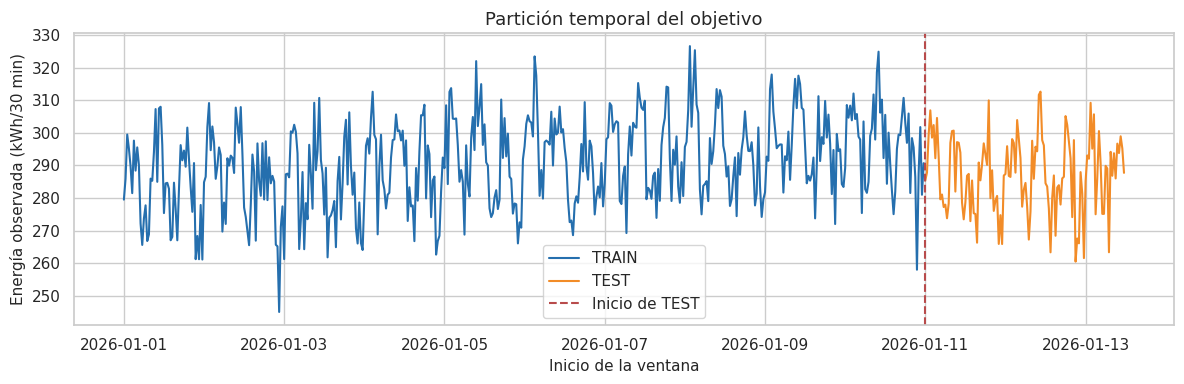

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_silver.loc[X_train.index, "timestamp_inicio"], y_train, label="TRAIN", color="#256FAE")
ax.plot(df_silver.loc[X_test.index, "timestamp_inicio"], y_test, label="TEST", color="#F28C28")
ax.axvline(fecha_test_inicio, color="#B84B4B", linestyle="--", linewidth=1.5, label="Inicio de TEST")
ax.set_title("Partición temporal del objetivo")
ax.set_xlabel("Inicio de la ventana")
ax.set_ylabel("Energía observada (kWh/30 min)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Baseline y regresores con preprocesamiento seguro

Compararemos tres estrategias mediante la misma interfaz `fit`/`predict`:

1. **DummyRegressor:** ignora $X$ y predice la media aprendida en TRAIN.
2. **Regresión Lineal:** incorpora `StandardScaler` dentro de un `Pipeline`.
3. **Random Forest:** captura interacciones no lineales y no requiere escalado para dividir los árboles.

El escalado puede mejorar el acondicionamiento numérico y la comparabilidad de variables en modelos sensibles a escala, pero **no es obligatorio para Random Forest**. Encapsularlo en un `Pipeline` evita ajustarlo accidentalmente con TEST.


In [ ]:
modelos = {
    "Dummy Baseline": DummyRegressor(strategy="mean"),
    "Regresión Lineal": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        random_state=SEMILLA,
        n_jobs=-1,
    ),
}

predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    predicciones[nombre] = {
        "train": modelo.predict(X_train),
        "test": modelo.predict(X_test),
    }

media_pipeline = modelos["Regresión Lineal"].named_steps["scaler"].mean_
print("Modelos ajustados exclusivamente con TRAIN.")
print("Media aprendida por el StandardScaler en TRAIN:")
display(pd.Series(media_pipeline, index=predictores, name="media_train"))


Modelos ajustados exclusivamente con TRAIN.
Media aprendida por el StandardScaler en TRAIN:


,media_train
temperatura_c,69.972
vibracion_mm_s,2.871
horas_desde_mantenimiento,119.750
produccion_plan_t_h,22.948


## 5. Evaluación común en TRAIN y TEST

- **MAE:** magnitud absoluta media del error, en kWh por ventana.
- **MSE:** promedio del error cuadrático, en kWh²; es útil para optimización, pero menos intuitivo para operación.
- **RMSE:** raíz del MSE, nuevamente en kWh; aumenta cuando existen errores grandes.
- **$R^2$:** desempeño relativo frente a predecir la media. Puede ser negativo y no expresa el error en unidades físicas.

La comparación debe realizarse con **las mismas filas de TEST y las mismas métricas** para todos los modelos.


In [ ]:
def calcular_metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_real, y_pred),
    }


filas = []
for nombre in modelos:
    train = calcular_metricas(y_train, predicciones[nombre]["train"])
    test = calcular_metricas(y_test, predicciones[nombre]["test"])
    filas.append({
        "Modelo": nombre,
        "MAE Train (kWh)": train["MAE"],
        "MAE Test (kWh)": test["MAE"],
        "MSE Test (kWh²)": test["MSE"],
        "RMSE Train (kWh)": train["RMSE"],
        "RMSE Test (kWh)": test["RMSE"],
        "R² Train": train["R2"],
        "R² Test": test["R2"],
        "Brecha R²": train["R2"] - test["R2"],
    })

tabla_resultados = pd.DataFrame(filas).set_index("Modelo")
print("=== COMPARACIÓN COMÚN DE MODELOS ===")
display(tabla_resultados)


=== COMPARACIÓN COMÚN DE MODELOS ===


,MAE Train (kWh),MAE Test (kWh),MSE Test (kWh²),RMSE Train (kWh),RMSE Test (kWh),R² Train,R² Test,Brecha R²
Modelo,,,,,,,,
Dummy Baseline,10.929,9.770,147.114,13.353,12.129,0.000,-0.107,0.107
Regresión Lineal,4.633,5.397,46.020,5.827,6.784,0.810,0.654,0.156
Random Forest,2.631,5.658,50.552,3.248,7.110,0.941,0.620,0.321


In [ ]:
rmse_baseline = tabla_resultados.loc["Dummy Baseline", "RMSE Test (kWh)"]
tabla_decision = tabla_resultados[["MAE Test (kWh)", "RMSE Test (kWh)", "R² Test", "Brecha R²"]].copy()
tabla_decision["Mejora RMSE vs baseline (%)"] = (
    100 * (rmse_baseline - tabla_decision["RMSE Test (kWh)"]) / rmse_baseline
)
tabla_decision["Supera baseline"] = tabla_decision["RMSE Test (kWh)"] < rmse_baseline
tabla_decision = tabla_decision.sort_values("RMSE Test (kWh)")

print("=== TABLA PARA LA DECISIÓN DIDÁCTICA ===")
display(tabla_decision)

mejor_modelo = tabla_decision.drop(index="Dummy Baseline").index[0]
print(f"Menor RMSE entre los regresores evaluados: {mejor_modelo}")


=== TABLA PARA LA DECISIÓN DIDÁCTICA ===


,MAE Test (kWh),RMSE Test (kWh),R² Test,Brecha R²,Mejora RMSE vs baseline (%),Supera baseline
Modelo,,,,,,
Regresión Lineal,5.397,6.784,0.654,0.156,44.070,True
Random Forest,5.658,7.110,0.620,0.321,41.381,True
Dummy Baseline,9.770,12.129,-0.107,0.107,0.000,False


Menor RMSE entre los regresores evaluados: Regresión Lineal


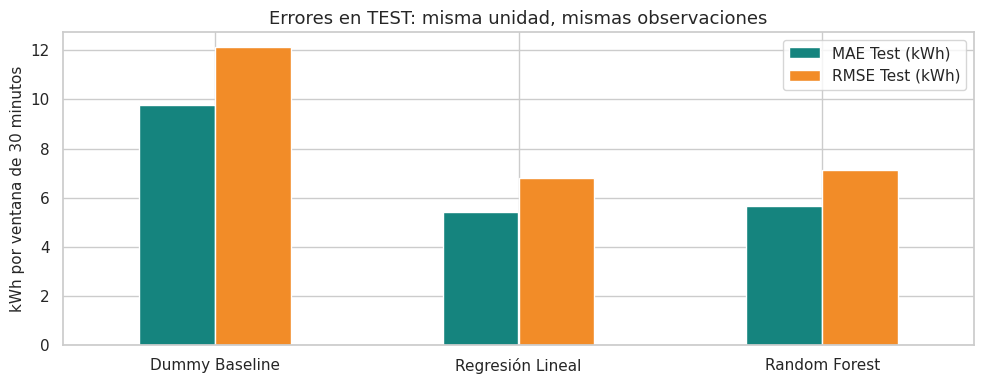

In [ ]:
metricas_test = tabla_resultados[["MAE Test (kWh)", "RMSE Test (kWh)"]].copy()
metricas_test.plot(kind="bar", figsize=(10, 4), color=["#15847E", "#F28C28"])
plt.title("Errores en TEST: misma unidad, mismas observaciones")
plt.ylabel("kWh por ventana de 30 minutos")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Diagnóstico de generalización

Una brecha entre TRAIN y TEST es una **señal de investigación**, no un diagnóstico automático. Antes de afirmar sobreajuste, revise:

- complejidad del modelo;
- fuga de información o transformaciones aprendidas con TEST;
- partición poco representativa;
- ruido, tamaño de muestra o variables insuficientes;
- cambio de distribución entre entrenamiento y prueba.

No seleccione un modelo únicamente por el $R^2$ más alto. Compruebe baseline, errores en unidades físicas, brecha y tolerancia operativa.


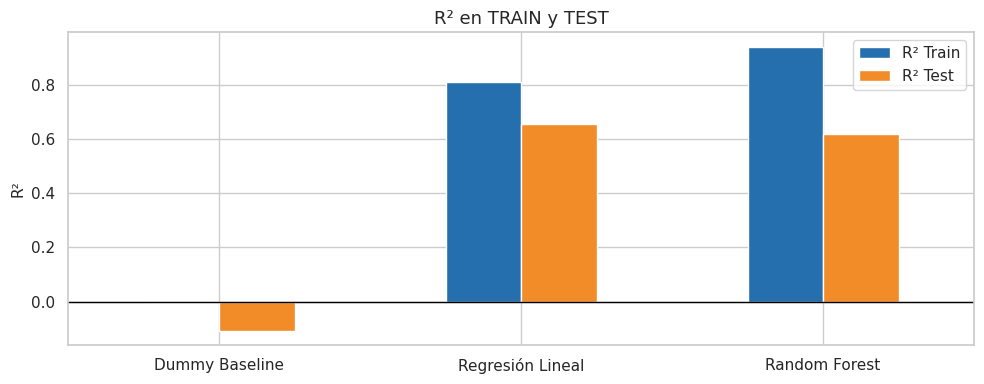

In [ ]:
comparacion_r2 = tabla_resultados[["R² Train", "R² Test"]]
comparacion_r2.plot(kind="bar", figsize=(10, 4), color=["#256FAE", "#F28C28"])
plt.axhline(0, color="black", linewidth=1)
plt.title("R² en TRAIN y TEST")
plt.ylabel("R²")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Análisis de residuos del regresor seleccionado

Los residuos son $y - \hat{y}$. Buscaremos sesgo alrededor de cero, patrones sistemáticos, dispersión creciente y errores extremos.

La normalidad de los residuos **no es un requisito general para que un modelo prediga**. Puede ser relevante para determinadas inferencias estadísticas, pero aquí la prioridad es detectar estructura no aprendida y riesgo operativo.


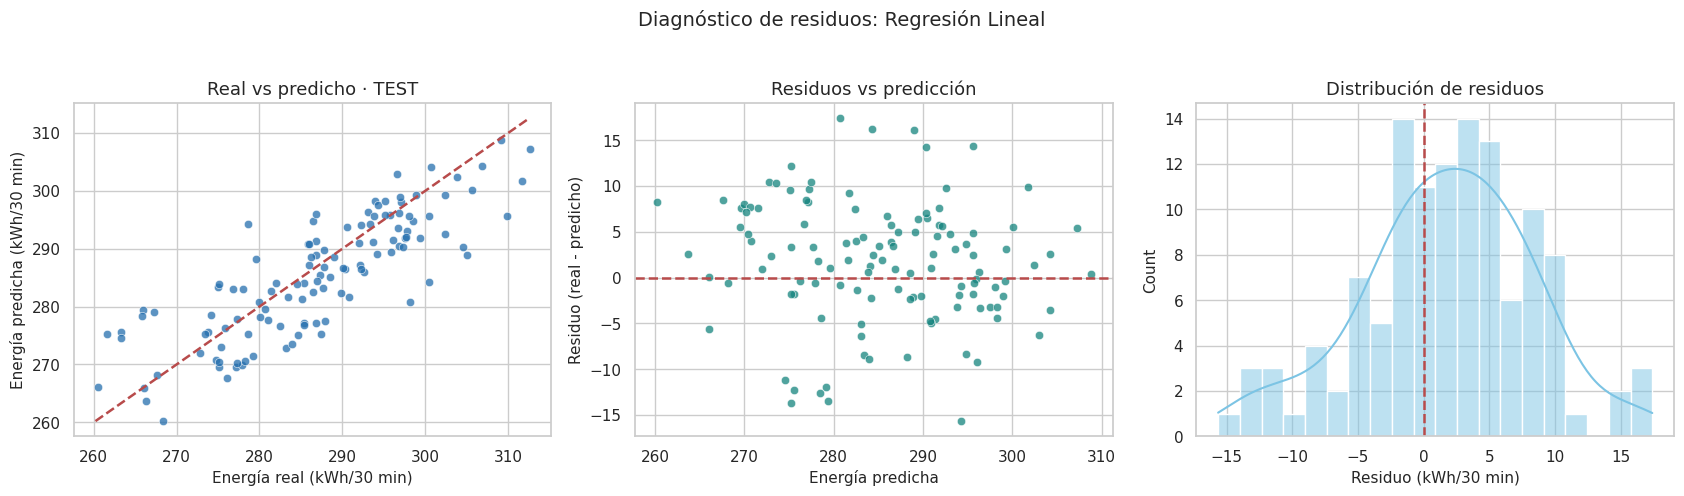

In [ ]:
y_pred_seleccionado = predicciones[mejor_modelo]["test"]
residuos = y_test.to_numpy() - y_pred_seleccionado

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.scatterplot(x=y_test, y=y_pred_seleccionado, ax=axes[0], color="#256FAE", alpha=0.75)
limites = [min(y_test.min(), y_pred_seleccionado.min()), max(y_test.max(), y_pred_seleccionado.max())]
axes[0].plot(limites, limites, "--", color="#B84B4B", linewidth=1.8)
axes[0].set_title("Real vs predicho · TEST")
axes[0].set_xlabel("Energía real (kWh/30 min)")
axes[0].set_ylabel("Energía predicha (kWh/30 min)")

sns.scatterplot(x=y_pred_seleccionado, y=residuos, ax=axes[1], color="#15847E", alpha=0.75)
axes[1].axhline(0, color="#B84B4B", linestyle="--", linewidth=1.8)
axes[1].set_title("Residuos vs predicción")
axes[1].set_xlabel("Energía predicha")
axes[1].set_ylabel("Residuo (real - predicho)")

sns.histplot(residuos, bins=20, kde=True, ax=axes[2], color="#7CC4E4")
axes[2].axvline(0, color="#B84B4B", linestyle="--", linewidth=1.8)
axes[2].set_title("Distribución de residuos")
axes[2].set_xlabel("Residuo (kWh/30 min)")

fig.suptitle(f"Diagnóstico de residuos: {mejor_modelo}", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
resumen_residuos = pd.Series({
    "Sesgo medio (kWh)": residuos.mean(),
    "Mediana (kWh)": np.median(residuos),
    "Desviación estándar (kWh)": residuos.std(ddof=1),
    "Percentil 95 del error absoluto (kWh)": np.percentile(np.abs(residuos), 95),
    "Máximo error absoluto (kWh)": np.abs(residuos).max(),
})

display(resumen_residuos.to_frame("Valor"))


,Valor
Sesgo medio (kWh),1.675
Mediana (kWh),2.135
Desviación estándar (kWh),6.601
Percentil 95 del error absoluto (kWh),13.726
Máximo error absoluto (kWh),17.420


## 7. Traducción económica: cálculo ilustrativo, no pérdida real

Si una tarifa eléctrica es conocida, `MAE × tarifa` aproxima la **magnitud media del error de estimación del costo energético por observación**. No demuestra ahorro, merma, lucro cesante ni impacto en OEE.

Para convertir el error en una decisión se necesitan, además, tolerancias del proceso, dirección del error, frecuencia de uso, costo de intervenir, costo de no intervenir y relación causal con calidad o producción.


In [ ]:
TARIFA_USD_KWH = 0.12  # Valor ilustrativo: reemplácelo por la tarifa autorizada de su caso.

mae_seleccionado = tabla_resultados.loc[mejor_modelo, "MAE Test (kWh)"]
error_costo_medio_usd = mae_seleccionado * TARIFA_USD_KWH

print(f"Modelo: {mejor_modelo}")
print(f"MAE en TEST: {mae_seleccionado:.2f} kWh por ventana")
print(f"Magnitud ilustrativa del error de costo: USD {error_costo_medio_usd:.2f} por ventana")
print("Advertencia: este valor no equivale a pérdida, ahorro, merma ni impacto en OEE.")


Modelo: Regresión Lineal
MAE en TEST: 5.40 kWh por ventana
Magnitud ilustrativa del error de costo: USD 0.65 por ventana
Advertencia: este valor no equivale a pérdida, ahorro, merma ni impacto en OEE.


## 8. Pausa de interpretación escrita

Responda con evidencia de las tablas y gráficos:

1. **¿Qué regresor generaliza mejor en TEST y cuánto mejora su RMSE respecto del baseline?**
2. **¿La brecha TRAIN/TEST sugiere un problema que deba investigarse?** Proponga al menos dos hipótesis; no diagnostique únicamente con dos números.
3. **¿Qué información adicional necesita para decidir si el MAE es tolerable para la planta?**
4. **¿Por qué la partición temporal usada aquí sería preferible a una aleatoria para este contrato predictivo?**
5. **¿Qué limitación del dataset sintético impide trasladar estas métricas directamente a producción?**

> **Respuesta del participante:**  
> Escriba aquí una interpretación breve y técnicamente justificada.


## 9. Plantilla para el Proyecto Integrador

Complete primero el contrato predictivo del equipo. Luego adapte la celda siguiente sin cambiar la lógica de evaluación:

| Elemento | Definición del equipo |
|---|---|
| Decisión que cambiará | ... |
| Unidad de observación | ... |
| Instante y horizonte | ... |
| Objetivo $y$ y unidad | ... |
| Predictores $X$ disponibles | ... |
| Estrategia de partición | temporal / grupos / aleatoria justificada |
| Tolerancia operativa del error | ... |


In [ ]:
# PLANTILLA: complete y descomente solo cuando el dataset grupal esté disponible.
# RUTA_DATASET = "/content/drive/MyDrive/.../dataset_silver.csv"
# df_proyecto = pd.read_csv(RUTA_DATASET)
# PREDICTORES_PROYECTO = ["variable_1", "variable_2"]
# OBJETIVO_PROYECTO = "objetivo_continuo"
#
# X_proyecto = df_proyecto[PREDICTORES_PROYECTO]
# y_proyecto = df_proyecto[OBJETIVO_PROYECTO]
#
# Antes de entrenar:
# 1) confirme disponibilidad temporal de X;
# 2) elija y justifique la partición;
# 3) ajuste transformaciones solo con TRAIN;
# 4) compare DummyRegressor y al menos un regresor en las mismas filas de TEST;
# 5) documente métricas, residuos, tolerancia y limitaciones.
print("Plantilla del Proyecto Integrador lista para completar.")


Plantilla del Proyecto Integrador lista para completar.


---
## Trabajo autónomo: 5 horas

1. **Lectura guiada — 1,0 h:** fugas de información, evaluación y métricas.
2. **Notebook Formativo 5 — 1,5 h:** concluir, ejecutar y documentar individualmente.
3. **Proyecto Integrador — 1,5 h:** aplicar baseline y regresor al dataset grupal.
4. **Diccionario de datos — 0,5 h:** registrar $X$, $y$, unidad, horizonte y disponibilidad.
5. **Verificación — 0,5 h:** reiniciar el entorno, ejecutar de principio a fin y comprobar permisos de solo lectura.

### Entregable grupal en Classroom

El cuaderno del proyecto debe contener:

- contrato predictivo completo;
- partición justificada y libre de fuga;
- `DummyRegressor` y al menos un regresor;
- tabla TEST con MAE, MSE, RMSE y $R^2$;
- análisis de residuos, tolerancia y limitaciones;
- enlace reproducible de solo lectura.

### Referencias oficiales

- [Scikit-Learn: errores comunes y fuga de datos](https://scikit-learn.org/stable/common_pitfalls.html)
- [Scikit-Learn: train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [Scikit-Learn: métricas y evaluación](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [Scikit-Learn: DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html)
